# FPUT Problem: Reference Trajectory Analysis and Validation

## Overview

This notebook provides analysis and validation of the reference trajectories generated by numerical simulations of the Fermi-Pasta-Ulam-Tsingou (FPUT) problem.

In particular, this notebook will:
1. Load and visualize reference trajectories for different initial conditions
2. Compute Taylor series approximations and compare against high-accuracy reference solutions

## Mathematical Model
Consider a chain of $2m$ mass points connected by alternating soft nonlinear springs and stiff linear springs. Let the displacements from equilibrium be given by $q_1, \ldots, q_{2m}$, with $q_0 = q_{2m+1} = 0$, and let the corresponding momenta be $p_i = d q_i/dt$. The Hamiltonian of this system is given by
\begin{align*}
    H(p,q) = \frac{1}{2} \sum_{i=1}^{m} (p_{2i-1}^2 + p_{2i}^{2}) + \frac{\omega^2}{4} \sum_{i=1}^{m} (q_{2i}-q_{2i-1})^2 +\sum_{i=0}^{m} (q_{2i+1}-q_{2i})^4,
\end{align*}
where $\omega \gg 1$ represents the high frequency of the stiff linear springs. 

To capture the multiscale behavior inherent in the FPUT system, we perform a change of variables that decouples the slow and fast components. For $i=1,\ldots,m$, define 
slow variables 
\begin{align*}
    x_{0,i} := \frac{1}{\sqrt{2}} (q_{2i} + q_{2i-1}), \quad y_{0,i} := \frac{1}{\sqrt{2}} (p_{2i} + p_{2i-1}),
\end{align*}
and fast variables
\begin{align*}
    x_{1,i} := \frac{1}{\sqrt{2}} (q_{2i} - q_{2i-1}), \quad y_{1,i} := \frac{1}{\sqrt{2}} (p_{2i} - p_{2i-1}).
\end{align*}

Physically, $x_{0,i}$ represents a scaled displacement of the i-th stiff spring, while $x_{1,i}$ characterizes its expansion or compression. Their corresponding momenta are $y_{0,i}$ and $y_{1,i}$. 

Rewriting the Hamiltonian in these new variables, we obtain 
\begin{align*}
    H(y,x) = &\frac{1}{2} \sum_{i=1}^{m} (y_{0,i}^2 + y_{1,i}^2) + \frac{\omega^2}{2} \sum_{i=1}^{m} x_{1,i}^2 \nonumber \\
    &+ \frac{1}{4}\left( (x_{0,1}-x_{1,1})^4 + \sum_{i=1}^{m-1} (x_{0,i+1}-x_{1,i+1}-x_{0,i}-x_{1,i})^4 + (x_{0,m}+x_{1,m})^4 \right).
\end{align*}
The kinetic energies corresponding to the slow and fast components are given by 
\begin{align*}
    T_0 = \frac{1}{2} \|y_0\|^2, \quad T_1 = \frac{1}{2} \|y_1\|^2.
\end{align*}

In addition to the conservation of the total energy, this system has an almost-invariant behavior in the stiff spring energies. Defining the energy of the $j$th stiff spring as
\begin{align*}
    I_j(y_{1,j},x_{1,j}) = \frac{1}{2}(y_{1,j}^2 + \omega^2 x_{1,j}^2),
\end{align*}
one finds that the total oscillatory energy 
\begin{align*}
    I=\sum_{j=1}^m{I_j}
\end{align*}
remains nearly constant (via the modulated Fourier expansion technique), satisfying
\begin{align*}
    I(y(t),x(t)) = I(y(0),x(0)) + \mathcal{O}(\omega^{-1}).
\end{align*}

## Setup and Dependencies 

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from notebook_utils.dataprocessing import FPU, FPUTrajectory, FPUDataset
from notebook_utils.visualization import FPUVisualizer

Trajectory = FPUTrajectory
Dataset = FPUDataset

viz = FPUVisualizer()

## Analysis

### 1. Reference Trajectory Analysis

We analyze reference trajectories for the FPUT problem with different frequency parameters and time scales to understand the multiscale dynamics.

In [2]:
# Set parameters
omega = 50.0

# Set initial condition index
traj_idx = 1

# Get reference trajectory filepaths
ref_filepaths = FPU.get_reference_filepaths("default")

# Load reference trajectory
ref_traj = Trajectory.load_from_file(
    ref_filepaths[omega][traj_idx]["filepath"], 
    dt=ref_filepaths[omega][traj_idx]["dt"],
    omega=omega,
)
print(f"Loaded trajectory: {ref_traj}")

# Create processor for computing derivatives and energies
processor = FPU(omega=omega)

Loaded trajectory: FPUTrajectory(t_range=[0.0, 500.0], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(128001, 12)))


=== O(1/omega) time scale analysis ===
Short time trajectory: FPUTrajectory(t_range=[0.0, 0.125], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(33, 12)))


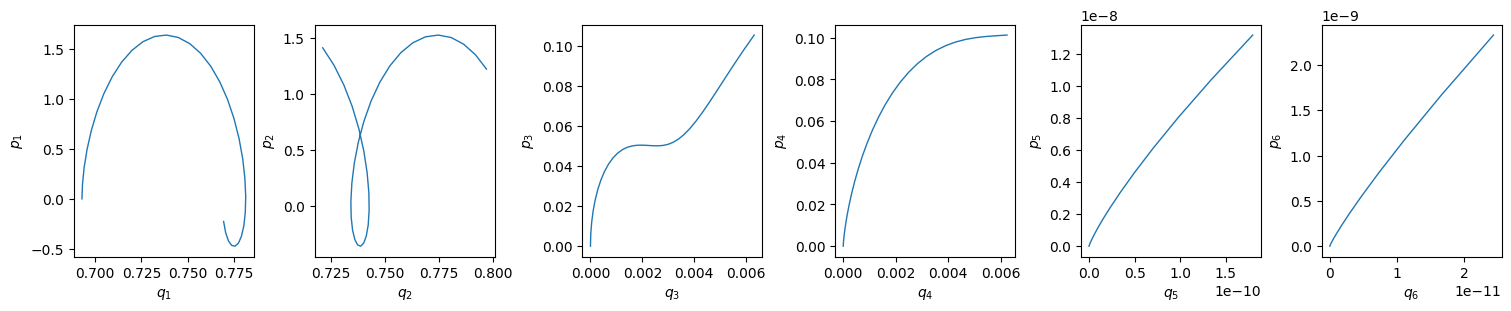

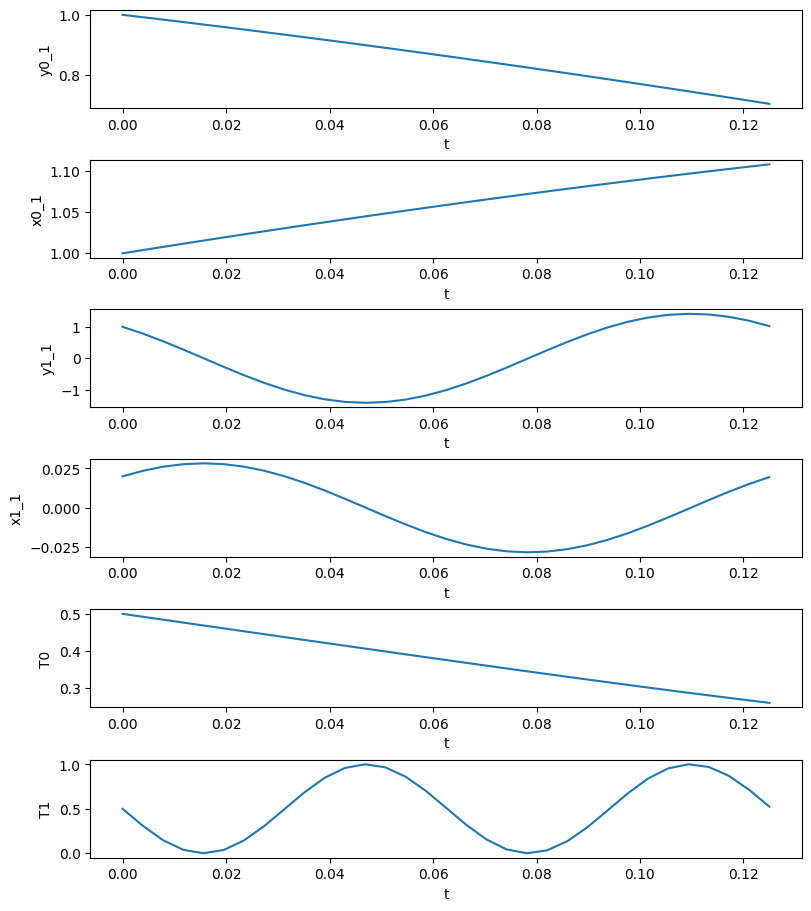

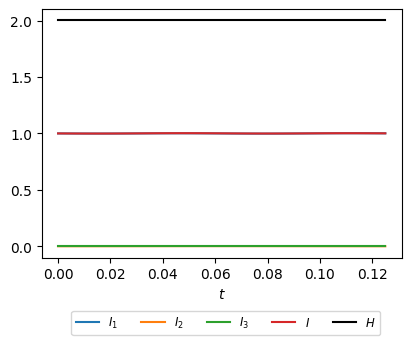

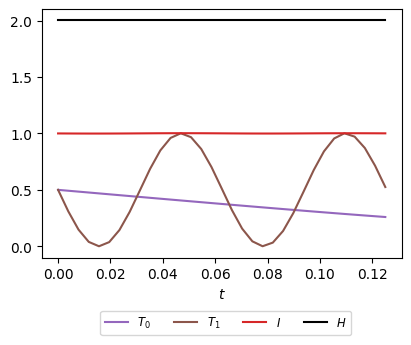

In [5]:
# O(1/omega) time scale - Fast oscillations
print("=== O(1/omega) time scale analysis ===")

# Define function dictionary for slow-fast coordinate analysis
func_dict = {
    "y0_1": lambda u: processor.get_slow_fast_coords(u)[0][:, 0],
    "x0_1": lambda u: processor.get_slow_fast_coords(u)[2][:, 0],
    "y1_1": lambda u: processor.get_slow_fast_coords(u)[1][:, 0],
    "x1_1": lambda u: processor.get_slow_fast_coords(u)[3][:, 0],
    "T0": processor.compute_T0,
    "T1": processor.compute_T1,
}

# Select short time window to capture fast oscillations
traj_short = ref_traj.select_between(0, 0.125)
print(f"Short time trajectory: {traj_short}")

# Plot phase space for all oscillators
viz.plot_phase_space([traj_short], figsize=(15, 3), show_legend=False)

# Plot slow-fast coordinate evolution
viz.plot_history([traj_short], func_dict=func_dict, show_legend=False)

# Plot energy analysis
viz.plot_stiff_spring_energies(
    traj_short
)
viz.plot_kinetic_energies(
    traj_short
)

In [12]:
# Plot energy analysis in MATLAB style
viz.plot_stiff_spring_energies_matlab(
    traj_short,
    figsize=(4, 3.5),
    ylim=(-0.2, 2.2),
    save_path="./out/fpu/stiff_spring_energies_ref_T_0_125.pdf"
)
viz.plot_kinetic_energies_matlab(
    traj_short,
    figsize=(4, 3.5),
    ylim=(-0.2, 2.2),
    save_path="./out/fpu/kinetic_energies_ref_T_0_125.pdf"
)


Current figure size: 4.0" x 3.5"
New figure size: 4.0" x 3.5"
Saved figure as: ./out/fpu/stiff_spring_energies_ref_T_0_125.pdf and ./out/fpu/stiff_spring_energies_ref_T_0_125.fig
Current figure size: 4.0" x 3.5"
New figure size: 4.0" x 3.5"
Saved figure as: ./out/fpu/kinetic_energies_ref_T_0_125.pdf and ./out/fpu/kinetic_energies_ref_T_0_125.fig


=== O(1) time scale analysis ===
Medium time trajectory: FPUTrajectory(t_range=[0.0, 3.0], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(769, 12)))


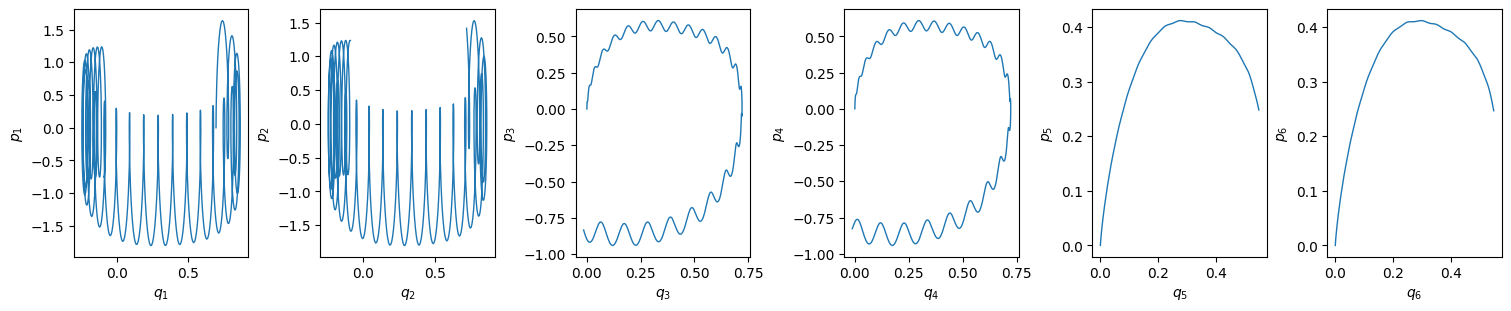

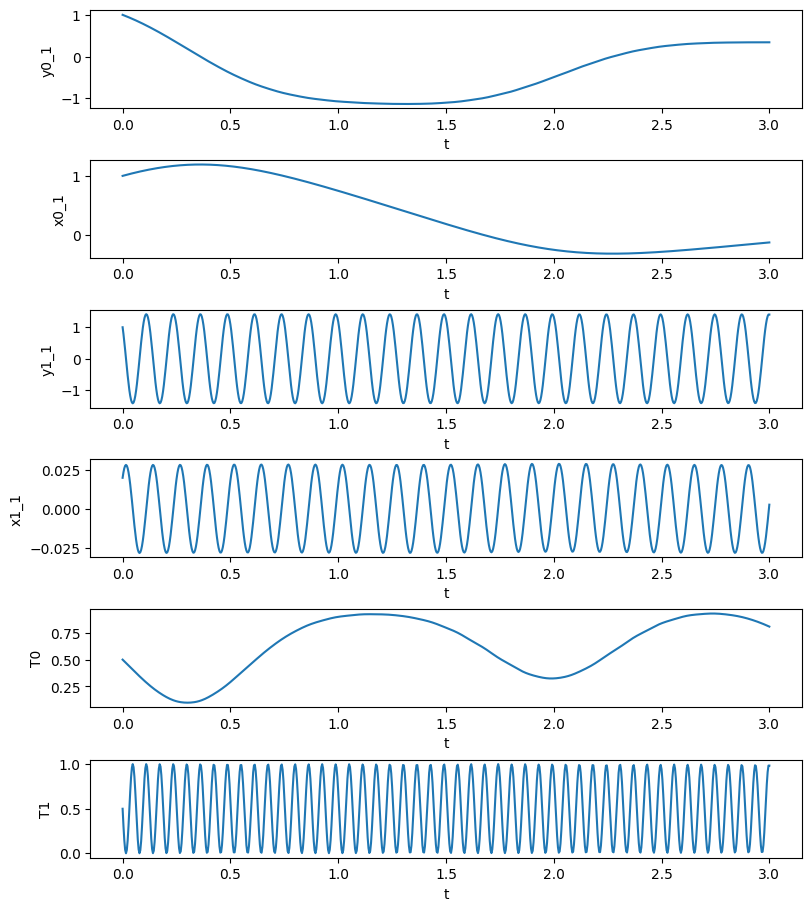

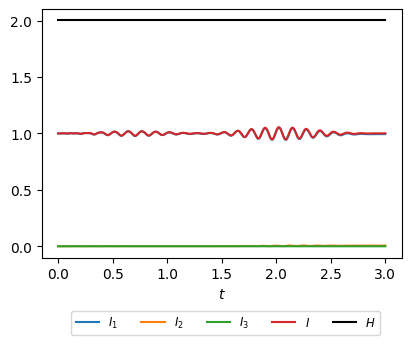

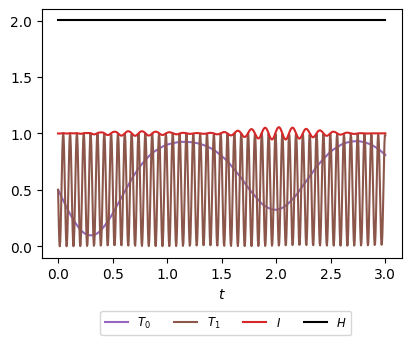

In [6]:
# O(1) time scale - Intermediate dynamics
print("=== O(1) time scale analysis ===")

# Select intermediate time window
traj_medium = ref_traj.select_between(0, 3)
print(f"Medium time trajectory: {traj_medium}")

# Plot phase space for all oscillators
viz.plot_phase_space([traj_medium], figsize=(15, 3), show_legend=False)

# Plot slow-fast coordinate evolution
viz.plot_history([traj_medium], func_dict=func_dict, show_legend=False)

# Plot energy analysis
viz.plot_stiff_spring_energies(
    traj_medium, 
)
viz.plot_kinetic_energies(
    traj_medium, 
)

In [11]:
# Plot energy analysis in MATLAB style
viz.plot_stiff_spring_energies_matlab(
    traj_medium,
    figsize=(4, 3.5),
    ylim=(-0.2, 2.2),
    save_path="./out/fpu/stiff_spring_energies_ref_T_3.pdf"
)
viz.plot_kinetic_energies_matlab(
    traj_medium,
    figsize=(4, 3.5),
    ylim=(-0.2, 2.2),
    save_path="./out/fpu/kinetic_energies_ref_T_3.pdf"
)


Current figure size: 4.0" x 3.5"
New figure size: 4.0" x 3.5"
Saved figure as: ./out/fpu/stiff_spring_energies_ref_T_3.pdf and ./out/fpu/stiff_spring_energies_ref_T_3.fig
Current figure size: 4.0" x 3.5"
New figure size: 4.0" x 3.5"
Saved figure as: ./out/fpu/kinetic_energies_ref_T_3.pdf and ./out/fpu/kinetic_energies_ref_T_3.fig


=== O(omega) time scale analysis ===
Long time trajectory: FPUTrajectory(t_range=[0.0, 200.0], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(51201, 12)))


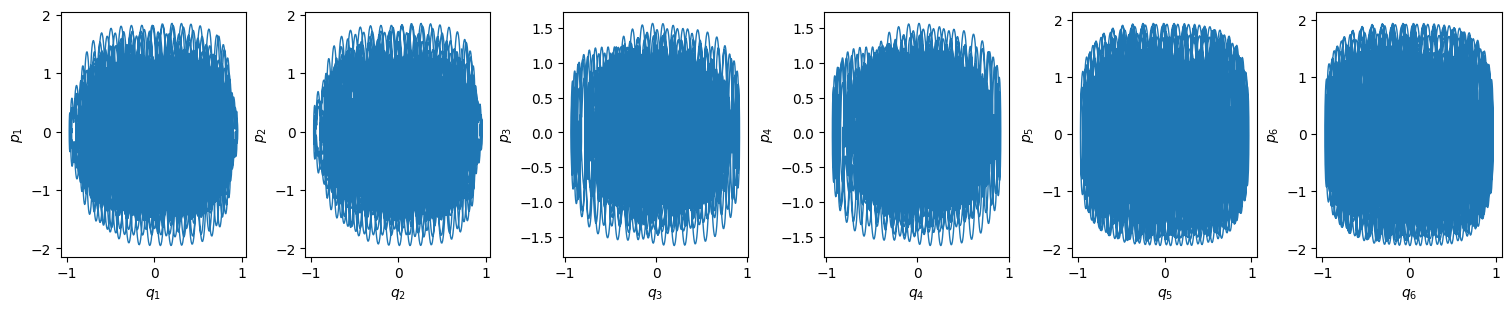

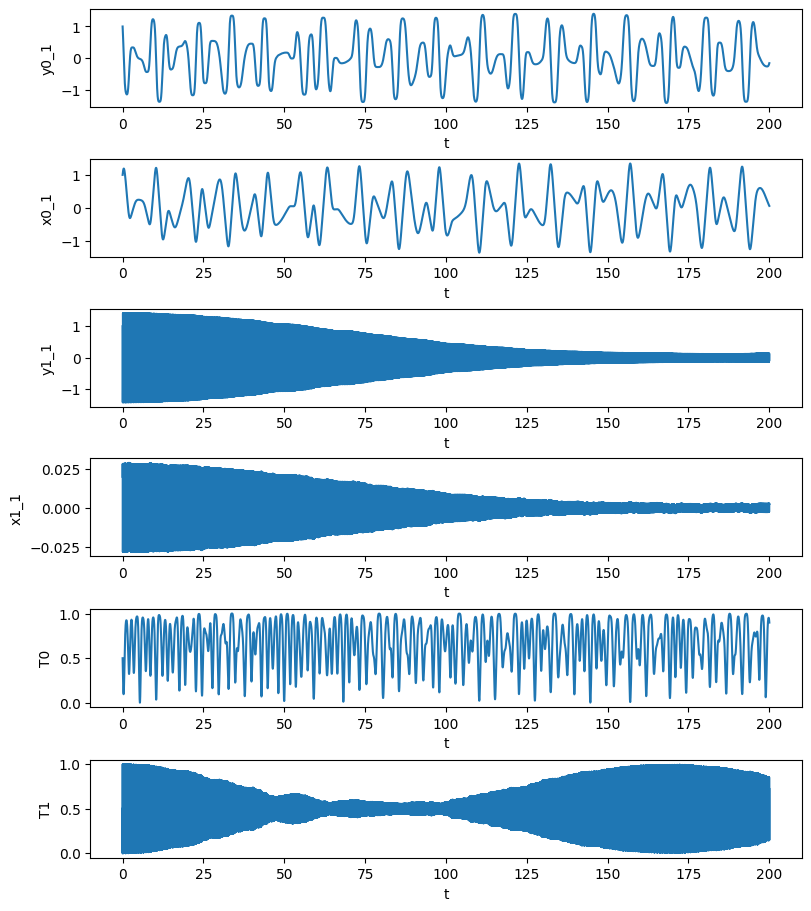

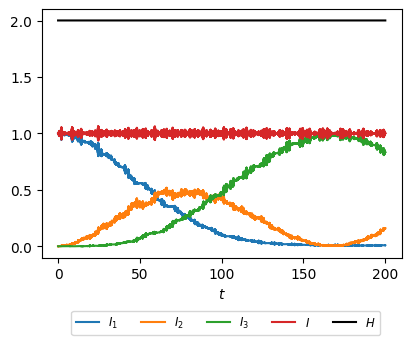

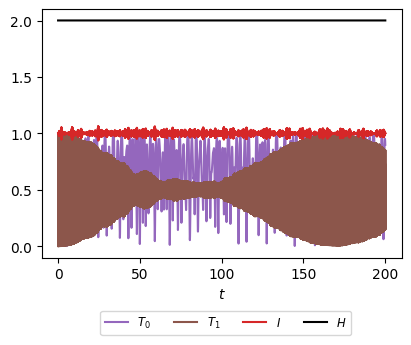

In [7]:
# O(omega) time scale - Long-term dynamics
print("=== O(omega) time scale analysis ===")

# Select long time window to observe long-term behavior
traj_long = ref_traj.select_between(0, 200)
print(f"Long time trajectory: {traj_long}")

# Plot phase space for all oscillators
viz.plot_phase_space([traj_long], figsize=(15, 3), show_legend=False)

# Plot slow-fast coordinate evolution
viz.plot_history([traj_long], func_dict=func_dict, show_legend=False)

# Plot energy analysis
viz.plot_stiff_spring_energies(
    traj_long, 
)
viz.plot_kinetic_energies(
    traj_long, 
)

In [10]:
# Plot energy analysis in MATLAB style
viz.plot_stiff_spring_energies_matlab(
    traj_long,
    figsize=(4, 3.5),
    ylim=(-0.2, 2.2),
    save_path="./out/fpu/stiff_spring_energies_ref_T_200.pdf"
)
viz.plot_kinetic_energies_matlab(
    traj_long,
    figsize=(4, 3.5),
    ylim=(-0.2, 2.2),
    save_path="./out/fpu/kinetic_energies_ref_T_200.pdf"
)


Current figure size: 4.0" x 3.5"
New figure size: 4.0" x 3.5"
Saved figure as: ./out/fpu/stiff_spring_energies_ref_T_200.pdf and ./out/fpu/stiff_spring_energies_ref_T_200.fig
Current figure size: 4.0" x 3.5"
New figure size: 4.0" x 3.5"
Saved figure as: ./out/fpu/kinetic_energies_ref_T_200.pdf and ./out/fpu/kinetic_energies_ref_T_200.fig


### 2. Taylor Series Approximation Validation

We validate the accuracy of Taylor series approximations by comparing them against high-precision reference solutions.

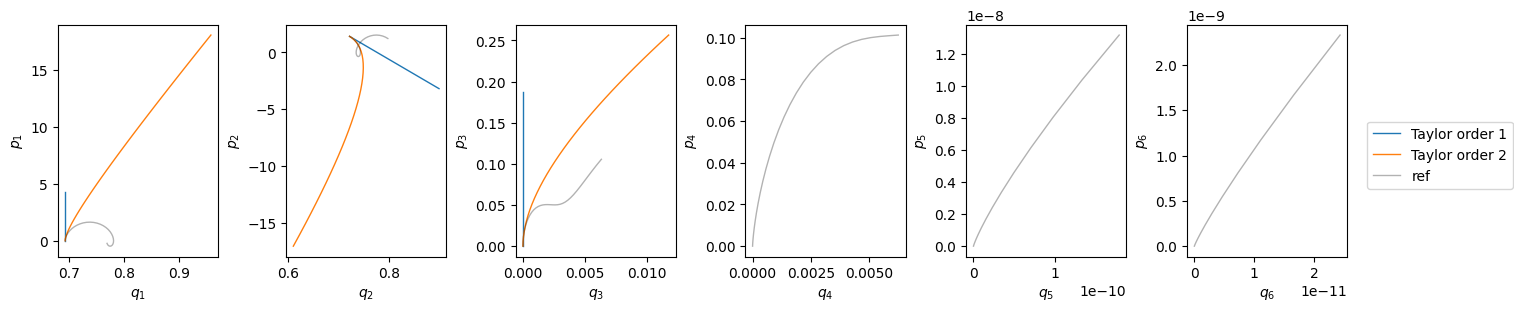

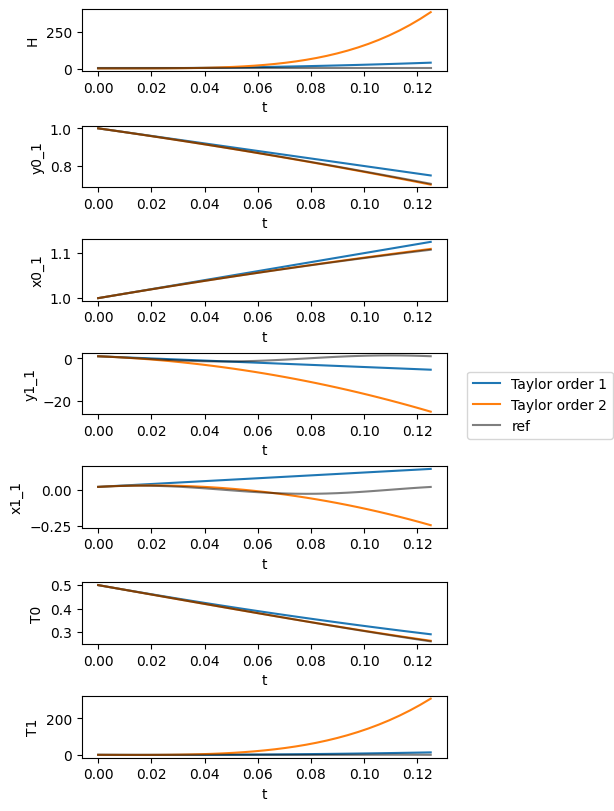

After alignment: 
	traj = FPUTrajectory(t_range=[0.0, 0.125], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(33, 12)))
	ref_traj = FPUTrajectory(t_range=[0.0, 0.125], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(33, 12)))
Taylor order 1 n=1 abs_traj_err = 0.017819832683835312
Taylor order 1 n=32 abs_traj_err = 6.2926120137790305
Taylor order 1 n=1 abs_H_err = 0.038382160999371084
Taylor order 1 n=32 abs_H_err = 39.319747925303005
Taylor order 1 n=1 abs_traj_err_y0 = 6.621656882569942e-05
Taylor order 1 n=32 abs_traj_err_y0 = 0.04644505539031691
Taylor order 1 n=1 abs_traj_err_x0 = 1.7372998771695254e-05
Taylor order 1 n=32 abs_traj_err_x0 = 0.01964521386675417
Taylor order 1 n=1 abs_traj_err_y1 = 0.

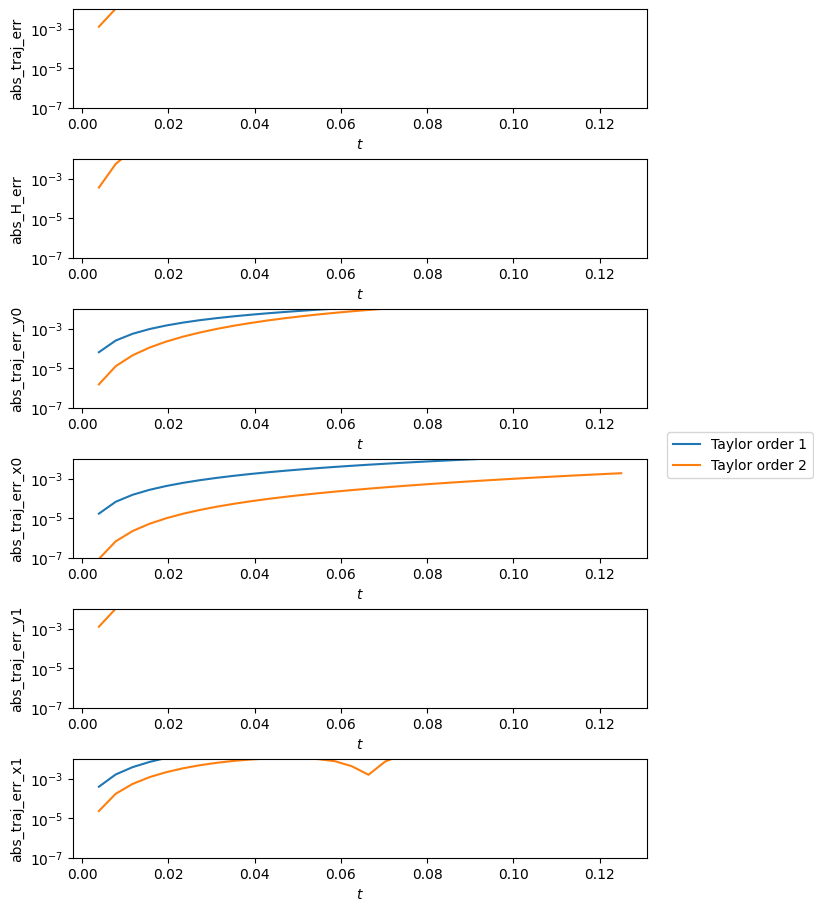

In [8]:
def trajectory_from_taylor_expansion(u0, times, p, order):
    """Generate trajectory using Taylor series expansion."""
    processor = FPU(**p)
    u = processor.compute_taylor_series(u0, times, order)
    return Trajectory.from_vx(times, u, **p)

# Set parameters for Taylor series validation
omega = 50.0
p = {"omega": omega}

# Set initial condition index
traj_idx = 1

# Load reference trajectory for validation
ref_filepaths = FPU.get_reference_filepaths("default")
ref_traj = Trajectory.load_from_file(
        ref_filepaths[omega][traj_idx]["filepath"], 
        dt=ref_filepaths[omega][traj_idx]["dt"],
        **p)
u0 = ref_traj.states.u[0]

# Select time window for Taylor series validation
ref_traj = ref_traj.select_between(0, 0.125)
times = ref_traj.times

# Generate Taylor series approximations
taylor_trajs = [trajectory_from_taylor_expansion(u0, times, p, order) for order in [1, 2]]
taylor_labels = ['Taylor order {}'.format(i) for i in [1, 2]]

# Create processor for analysis
fpu = FPU(**p)
func_dict = {
    "H": fpu.compute_hamiltonian,
    "y0_1": lambda u: fpu.get_slow_fast_coords(u)[0][:, 0],
    "x0_1": lambda u: fpu.get_slow_fast_coords(u)[2][:, 0],
    "y1_1": lambda u: fpu.get_slow_fast_coords(u)[1][:, 0],
    "x1_1": lambda u: fpu.get_slow_fast_coords(u)[3][:, 0],
    "T0": fpu.compute_T0,
    "T1": fpu.compute_T1,
}

# Plot phase space comparison
viz.plot_phase_space(
    taylor_trajs + [ref_traj],
    legend_labels=taylor_labels + ['ref'],
    show_legend=True,
    figsize=(15, 3)
)

# Plot time history of various quantities
viz.plot_history(
    taylor_trajs + [ref_traj],
    func_dict=func_dict,
    legend_labels=taylor_labels + ['ref'],
    show_legend=True,
    figsize=(6, 8),
)

# Plot error analysis
viz.plot_errors(
    taylor_trajs, ref_traj, 
    error_names=["abs_traj_err", "abs_H_err", "abs_traj_err_y0", "abs_traj_err_x0", "abs_traj_err_y1", "abs_traj_err_x1"],
    ylims=[(1e-7, 1e-2)] * 6,
    figsize=(8, 6), 
    legend_labels=taylor_labels,
    show_legend=True,
    log_yscale=True
)


In [4]:
viz.plot_history_matlab(
    taylor_trajs + [ref_traj],
    func_dict=func_dict,
    legend_labels=taylor_labels + ['ref'],
    show_legend=True,
    figsize=(6, 8),
    save_path="./out/fpu/taylor_history_ref_T_0_125.pdf"
)

Current figure size: 6.0" x 8.0"
New figure size: 6.0" x 8.0"
Saved figure as: ./out/fpu/taylor_history_ref_T_0_125.pdf and ./out/fpu/taylor_history_ref_T_0_125.fig


In [6]:
viz.plot_errors_matlab(
    taylor_trajs, ref_traj, 
    error_names=["abs_traj_err", "abs_H_err", "abs_traj_err_y0", "abs_traj_err_x0", "abs_traj_err_y1", "abs_traj_err_x1"],
    ylims=[(1e-7, 1e-2)] * 6,
    figsize=(4, 8), 
    legend_labels=taylor_labels,
    show_legend=True,
    log_yscale=True,
    save_path="./out/fpu/errors_ref_T_0_125.pdf"
)

After alignment: 
	traj = FPUTrajectory(t_range=[0.0, 0.125], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(33, 12)))
	ref_traj = FPUTrajectory(t_range=[0.0, 0.125], dt=0.00390625, u0=[0.         1.41421356 0.         0.         0.         0.
 0.69296465 0.72124892 0.         0.         0.         0.        ], states=States(problem=FPU(omega=50.0), shape=(33, 12)))
Taylor order 1 n=1 abs_traj_err = 0.017819832683835312
Taylor order 1 n=32 abs_traj_err = 6.2926120137790305
Taylor order 1 n=1 abs_H_err = 0.038382160999371084
Taylor order 1 n=32 abs_H_err = 39.319747925303005
Taylor order 1 n=1 abs_traj_err_y0 = 6.621656882569942e-05
Taylor order 1 n=32 abs_traj_err_y0 = 0.04644505539031691
Taylor order 1 n=1 abs_traj_err_x0 = 1.7372998771695254e-05
Taylor order 1 n=32 abs_traj_err_x0 = 0.01964521386675417
Taylor order 1 n=1 abs_traj_err_y1 = 0.